# Notebook 03 — Exploratory Analysis of Traffic Patterns

## Objective
Describe major temporal and spatial traffic-demand patterns so forecasting and optimization stages are grounded in clear empirical evidence.

## Background / Context
Using processed hourly and daily datasets, this notebook establishes how demand varies by year, month, day type, hour, and location. These observations guide where and when signal optimization is most likely to produce operational benefit.

## Methodology
The EDA workflow checks data quality, profiles long-horizon trends, evaluates weekly and hourly patterns, and ranks high-demand and high-pressure locations.

## Implementation
Each analysis block is followed by interpretation text to connect charts to capstone decisions.

## Implementation — Data Overview

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-whitegrid")


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    return start


repo_root = find_repo_root(Path.cwd())
daily_path = repo_root / "data" / "processed" / "modeling_dataset_2015_2019.csv"
hourly_path = repo_root / "data" / "processed" / "traffic_signal_hourly_dataset_2015_2019.csv"

for path in [daily_path, hourly_path]:
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}. Run notebooks/00_raw_preprocessing.ipynb first.")

daily_df = pd.read_csv(daily_path, parse_dates=["date"])
hourly_df = pd.read_csv(hourly_path, parse_dates=["hour", "date"])

print(f"Loaded daily dataset: {daily_path}")
print(f"Loaded hourly dataset: {hourly_path}")
print(f"daily_df.shape: {daily_df.shape[0]} rows x {daily_df.shape[1]} columns")
print(f"hourly_df.shape: {hourly_df.shape[0]} rows x {hourly_df.shape[1]} columns")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})


Loaded daily dataset: /Users/manavparikh/Documents/GitHub/unfc-capstone-traffic-forecasting/data/processed/modeling_dataset_2015_2019.csv
Loaded hourly dataset: /Users/manavparikh/Documents/GitHub/unfc-capstone-traffic-forecasting/data/processed/traffic_signal_hourly_dataset_2015_2019.csv
daily_df.shape: 5778 rows x 16 columns
hourly_df.shape: 138672 rows x 21 columns


In [2]:
display(daily_df.head())


,location_id,date,location_name,centreline_id,direction,year,month,day_of_week,is_weekend,daily_total_volume,peak_hour_volume,observed_hour_count,avg_observed_hourly_volume,peak_ratio,peak_hour_concentration,queue_pressure_proxy
0,10010625_WB,2015-05-14,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015,5,3,0,17031,1809,24,709.625000,0.106218,2.549234,1099.375000
1,10010625_WB,2015-05-15,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015,5,4,0,17365,1734,24,723.541667,0.099856,2.396545,1010.458333
2,10010625_WB,2015-05-16,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015,5,5,1,14470,1066,24,602.916667,0.073670,1.768072,463.083333
3,10010625_WB,2015-05-17,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015,5,6,1,12235,973,24,509.791667,0.079526,1.908623,463.208333
4,10010625_WB,2015-05-18,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015,5,0,0,16523,1775,24,688.458333,0.107426,2.578224,1086.541667


In [3]:
display(daily_df.describe(include='all').T)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
location_id,5778,914,103009_NB,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,5778,NaN,NaN,NaN,2016-12-06 12:22:25.794392,2015-03-31 00:00:00,2015-06-04 06:00:00,2016-06-04 00:00:00,2018-06-02 00:00:00,2019-11-05 00:00:00,NaN
location_name,5778,711,Sewells Rd: Old Finch Ave - Steeles Ave E,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
centreline_id,5778.0,NaN,NaN,NaN,10477128.899446,415.0,906778.0,7792640.5,14037408.0,60042531.0,12973711.664557
direction,5778,4,NB,1460,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,5778.0,NaN,NaN,NaN,2016.472655,2015.0,2015.0,2016.0,2018.0,2019.0,1.397479
month,5778.0,NaN,NaN,NaN,6.109034,1.0,5.0,6.0,8.0,12.0,2.895721
day_of_week,5778.0,NaN,NaN,NaN,2.674974,0.0,1.0,2.0,4.0,6.0,1.783097
is_weekend,5778.0,NaN,NaN,NaN,0.196435,0.0,0.0,0.0,0.0,1.0,0.397335
daily_total_volume,5778.0,NaN,NaN,NaN,10875.843891,0.0,7235.5,10792.5,14577.75,40994.0,5835.897287


## Implementation — Missing Values and Data Quality

In [4]:
missing_counts = daily_df.isna().sum().sort_values(ascending=False)
display(missing_counts[missing_counts > 0].to_frame("missing_count"))


,missing_count
peak_ratio,1
peak_hour_concentration,1


In [5]:
quality_flags = {
    "duplicate_daily_rows": int(daily_df.duplicated().sum()),
    "duplicate_hourly_rows": int(hourly_df.duplicated().sum()),
    "negative_daily_total_volume": int((daily_df["daily_total_volume"] < 0).sum()),
    "negative_peak_hour_volume": int((daily_df["peak_hour_volume"] < 0).sum()),
    "invalid_peak_ratio_lt_0": int((daily_df["peak_ratio"] < 0).sum()),
    "invalid_peak_ratio_gt_1": int((daily_df["peak_ratio"] > 1).sum()),
}

display(pd.Series(quality_flags, name="count"))


duplicate_daily_rows           0
duplicate_hourly_rows          0
negative_daily_total_volume    0
negative_peak_hour_volume      0
invalid_peak_ratio_lt_0        0
invalid_peak_ratio_gt_1        0
Name: count, dtype: int64

In [6]:
def iqr_outlier_count(series: pd.Series) -> int:
    x = series.dropna()
    if x.empty:
        return 0
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return 0
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return int(((x < lo) | (x > hi)).sum())


outlier_report = {
    c: iqr_outlier_count(daily_df[c])
    for c in ["daily_total_volume", "peak_hour_volume", "peak_ratio", "peak_hour_concentration"]
    if c in daily_df.columns
}

display(pd.Series(outlier_report, name="iqr_outlier_rows"))


daily_total_volume          62
peak_hour_volume            65
peak_ratio                 384
peak_hour_concentration    384
Name: iqr_outlier_rows, dtype: int64

In [7]:
# Validate core datetime and key-volume fields used by this EDA notebook.
required_daily_cols = {'date', 'daily_total_volume', 'peak_hour_volume', 'peak_ratio'}
missing_daily = sorted(required_daily_cols - set(daily_df.columns))
if missing_daily:
    raise ValueError('daily_df is missing required columns: ' + ', '.join(missing_daily))

required_hourly_cols = {'hour', 'hourly_volume', 'location_id'}
missing_hourly = sorted(required_hourly_cols - set(hourly_df.columns))
if missing_hourly:
    raise ValueError('hourly_df is missing required columns: ' + ', '.join(missing_hourly))

# Standardize datetime columns defensively.
daily_df['date'] = pd.to_datetime(daily_df['date'], errors='coerce')
hourly_df['hour'] = pd.to_datetime(hourly_df['hour'], errors='coerce')

if daily_df['date'].isna().all():
    raise ValueError("Could not parse any valid dates from daily_df['date'].")
if hourly_df['hour'].isna().all():
    raise ValueError("Could not parse any valid timestamps from hourly_df['hour'].")

invalid_daily_volume = (pd.to_numeric(daily_df['daily_total_volume'], errors='coerce') < 0).sum()
invalid_hourly_volume = (pd.to_numeric(hourly_df['hourly_volume'], errors='coerce') < 0).sum()

print(
    f"Daily coverage: {daily_df['date'].min():%Y-%m-%d} to {daily_df['date'].max():%Y-%m-%d} across "
    f"{daily_df['location_id'].nunique():,} locations."
)
print(
    f"Hourly coverage: {hourly_df['hour'].min():%Y-%m-%d %H:%M} to {hourly_df['hour'].max():%Y-%m-%d %H:%M} across "
    f"{hourly_df['location_id'].nunique():,} locations."
)

quality_snapshot = pd.DataFrame(
    {
        'check': [
            'missing daily dates',
            'missing hourly timestamps',
            'negative daily_total_volume',
            'negative hourly_volume',
        ],
        'count': [
            int(daily_df['date'].isna().sum()),
            int(hourly_df['hour'].isna().sum()),
            int(invalid_daily_volume),
            int(invalid_hourly_volume),
        ],
    }
)
display(quality_snapshot)


Daily coverage: 2015-03-31 to 2019-11-05 across 914 locations.
Hourly coverage: 2015-03-31 00:00 to 2019-11-05 23:00 across 914 locations.


,check,count
0,missing daily dates,0
1,missing hourly timestamps,0
2,negative daily_total_volume,0
3,negative hourly_volume,0


## Results — Traffic Demand Trends Over Time

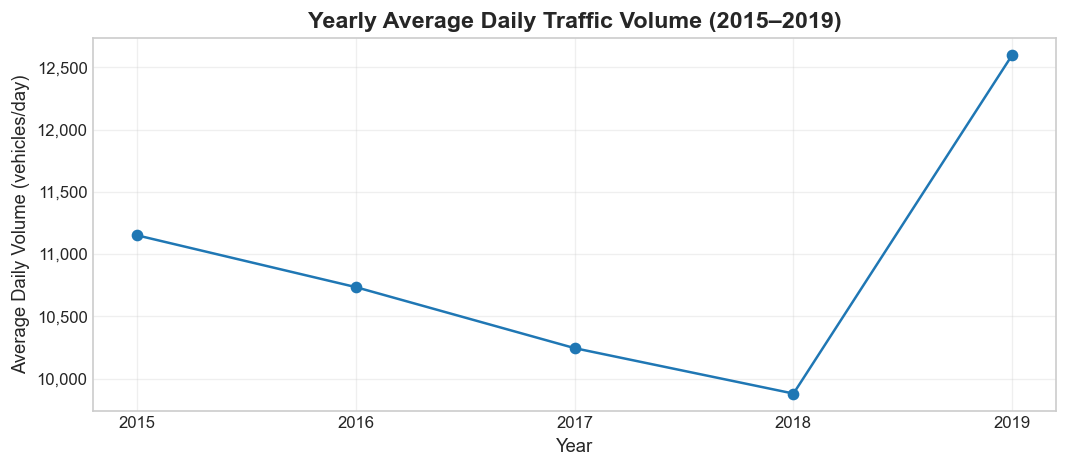

In [8]:
yearly = (
    daily_df.dropna(subset=["date", "daily_total_volume"])
    .groupby(daily_df["date"].dt.year, as_index=False)["daily_total_volume"]
    .mean()
)

# Ensure year labels are integers (not floats like 2019.0)
yearly["year"] = yearly["date"].astype(int)

plt.figure(figsize=(9, 4))
plt.plot(yearly["year"], yearly["daily_total_volume"], marker="o")

ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.title("Yearly Average Daily Traffic Volume (2015–2019)", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Average Daily Volume (vehicles/day)")

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Visual Description
This visual presents yearly average daily traffic volume. The horizontal axis reports year, and the vertical axis reports average daily traffic volume. Together, the figure provides a direct summary of the traffic pattern, model comparison, or operational outcome under study.

### Insight
The main value of this visual is that it makes relative differences immediately visible, which helps confirm whether traffic demand is not uniform across time or space, which is exactly why forecasting and targeted optimization are necessary. That perspective supports clearer discussion of congestion conditions, forecasting performance, and signal-timing decisions during presentation.

This yearly pattern functions as a baseline stability check. The key insight is whether demand is sufficiently consistent for robust baseline modeling, not whether long-term extrapolation is attempted.

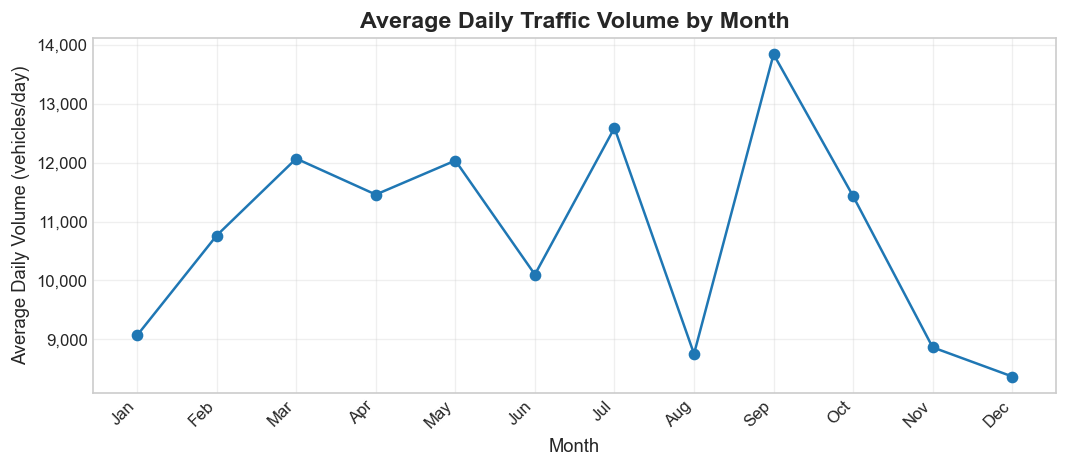

In [9]:
import calendar

monthly = (
    daily_df.dropna(subset=["date", "daily_total_volume"])
    .assign(month=daily_df["date"].dt.month)
    .groupby("month", as_index=False)["daily_total_volume"]
    .mean()
)

month_names = [calendar.month_abbr[i] for i in range(1, 13)]

plt.figure(figsize=(9, 4))
plt.plot(monthly["month"], monthly["daily_total_volume"], marker="o")
plt.xticks(range(1, 13), month_names, rotation=45, ha="right")
plt.title("Average Daily Traffic Volume by Month", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Average Daily Volume (vehicles/day)")
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Visual Description
This visual presents monthly variation in traffic volume. The horizontal axis reports month, and the vertical axis reports average daily traffic volume. Together, the figure provides a direct summary of the traffic pattern, model comparison, or operational outcome under study.

### Insight
The main value of this visual is that it makes relative differences immediately visible, which helps confirm whether traffic demand is not uniform across time or space, which is exactly why forecasting and targeted optimization are necessary. That perspective supports clearer discussion of congestion conditions, forecasting performance, and signal-timing decisions during presentation.

Monthly variation highlights seasonal strength and weakness in observed demand. This supports practical decisions about whether one static timing plan is sufficient or whether seasonal adjustments should be considered.

## Results — Weekly and Peak-Hour Patterns

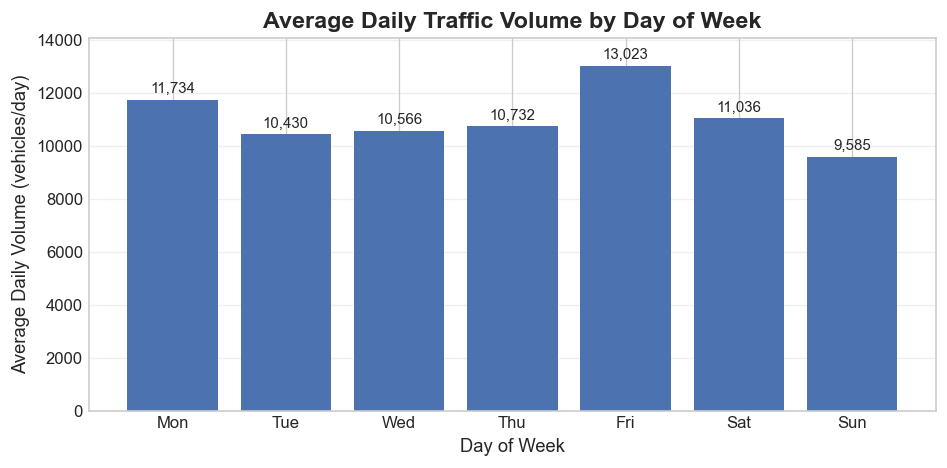

In [10]:
dow_src = daily_df.dropna(subset=["day_of_week", "daily_total_volume"]).copy()
dow_src["day_of_week"] = pd.to_numeric(dow_src["day_of_week"], errors="coerce")

dow = (
    dow_src.dropna(subset=["day_of_week"])
    .groupby("day_of_week", as_index=False)
    .agg(daily_total_volume=("daily_total_volume", "mean"))
    .sort_values(by="day_of_week")
    .reset_index(drop=True)
)

dow["day_of_week"] = dow["day_of_week"].astype(int)
name_map = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
dow["day_name"] = dow["day_of_week"].map(name_map)

plt.figure(figsize=(8, 4))
bars = plt.bar(dow["day_name"], dow["daily_total_volume"], color="#4C72B0")
plt.title("Average Daily Traffic Volume by Day of Week", fontsize=14, fontweight="bold")
plt.xlabel("Day of Week")
plt.ylabel("Average Daily Volume (vehicles/day)")
plt.grid(alpha=0.3, axis="y")

# Add headroom so bar labels don't touch the plot boundary
ax = plt.gca()
y_max = dow["daily_total_volume"].max() * 1.08
ax.set_ylim(0, y_max)

# Annotate bar values for easier reading
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + (y_max * 0.01),
        f"{int(round(height)):,}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()


### Visual Description
This visual presents average traffic volume by day of week. The horizontal axis reports day of week, and the vertical axis reports average daily traffic volume. Together, the figure provides a direct summary of the traffic pattern, model comparison, or operational outcome under study.

### Insight
The main value of this visual is that it makes relative differences immediately visible, which helps confirm whether traffic demand is not uniform across time or space, which is exactly why forecasting and targeted optimization are necessary. That perspective supports clearer discussion of congestion conditions, forecasting performance, and signal-timing decisions during presentation.

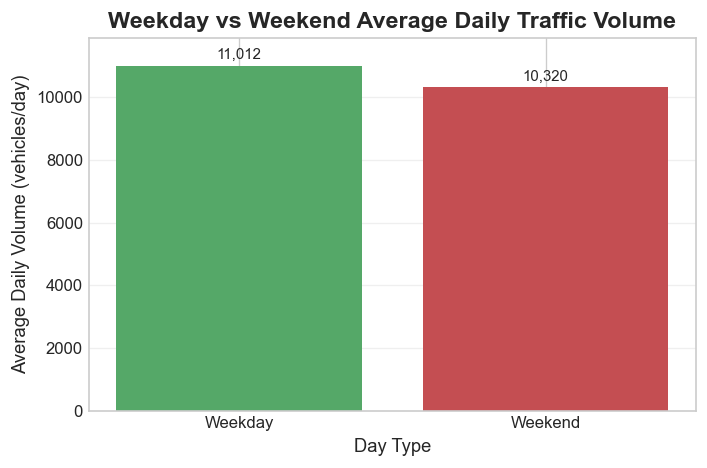

In [11]:
day_type = (
    daily_df.dropna(subset=["is_weekend", "daily_total_volume"])
    .assign(day_type=np.where(daily_df["is_weekend"] == 1, "Weekend", "Weekday"))
    .groupby("day_type", as_index=False)["daily_total_volume"]
    .mean()
)

order = ["Weekday", "Weekend"]
day_type = day_type.set_index("day_type").reindex(order).reset_index()

plt.figure(figsize=(6, 4))
bars = plt.bar(day_type["day_type"], day_type["daily_total_volume"], color=["#55A868", "#C44E52"])
plt.title("Weekday vs Weekend Average Daily Traffic Volume", fontsize=14, fontweight="bold")
plt.xlabel("Day Type")
plt.ylabel("Average Daily Volume (vehicles/day)")
plt.grid(alpha=0.3, axis="y")

# Add headroom so bar labels don't touch the plot boundary
ax = plt.gca()
y_max = day_type["daily_total_volume"].max() * 1.08
ax.set_ylim(0, y_max)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + (y_max * 0.01),
        f"{int(round(height)):,}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()


### Visual Description
This visual presents weekday vs weekend traffic volume. The horizontal axis reports day type, and the vertical axis reports average daily traffic volume. Together, the figure provides a direct summary of the traffic pattern, model comparison, or operational outcome under study.

### Insight
The main value of this visual is that it makes relative differences immediately visible, which helps confirm whether traffic demand is not uniform across time or space, which is exactly why forecasting and targeted optimization are necessary. That perspective supports clearer discussion of congestion conditions, forecasting performance, and signal-timing decisions during presentation.

Weekday-weekend differences indicate that commuter-driven weekday profiles warrant greater emphasis in peak-focused timing strategies than weekend periods.

## Results — Peak-Hour Demand Analysis

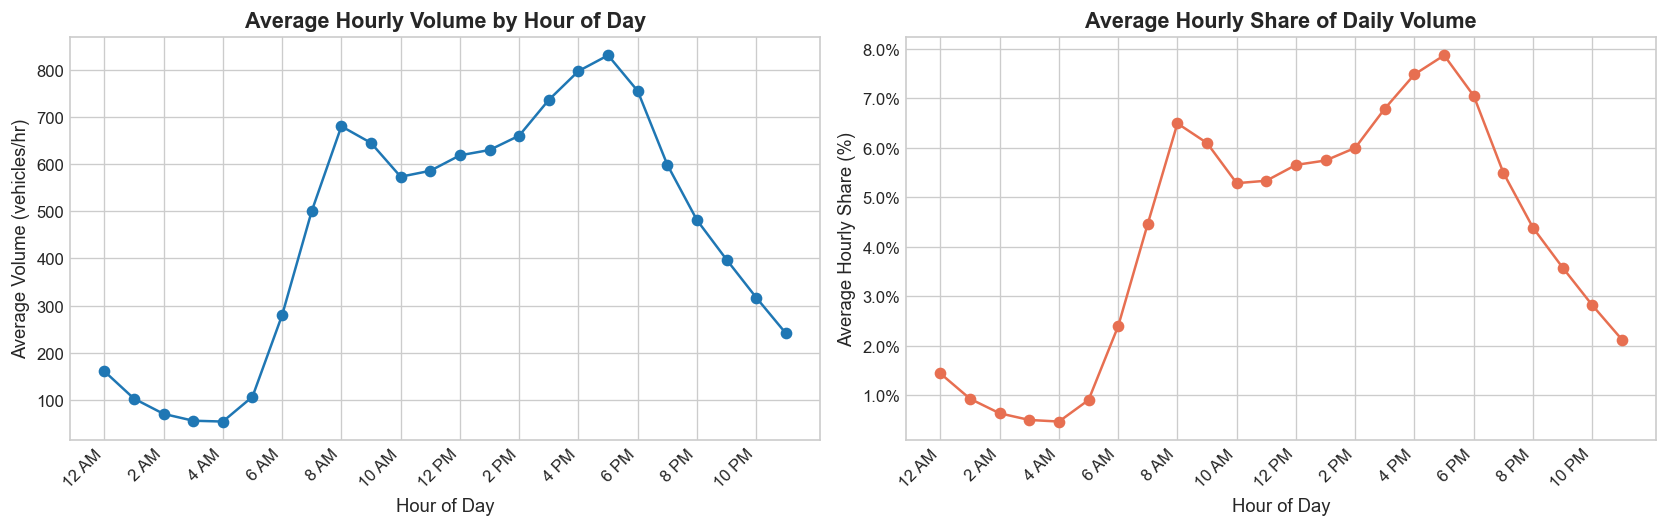

In [12]:
hourly_profile = (
    hourly_df.dropna(subset=["hour_of_day", "hourly_volume"])
    .groupby("hour_of_day", as_index=False)
    .agg(
        avg_hourly_volume=("hourly_volume", "mean"),
        avg_hourly_share=("hourly_share_of_daily_volume", "mean"),
    )
)

# Convert share to percentage for readability
hourly_profile["avg_hourly_share_pct"] = hourly_profile["avg_hourly_share"] * 100

# Create human-readable time labels (12 AM, 2 AM, ..., 10 PM)
hour_ticks = list(range(0, 24, 2))
hour_labels = []
for h in hour_ticks:
    if h == 0:
        hour_labels.append("12 AM")
    elif h < 12:
        hour_labels.append(f"{h} AM")
    elif h == 12:
        hour_labels.append("12 PM")
    else:
        hour_labels.append(f"{h - 12} PM")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(hourly_profile["hour_of_day"], hourly_profile["avg_hourly_volume"], marker="o")
axes[0].set_title("Average Hourly Volume by Hour of Day", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Average Volume (vehicles/hr)")
axes[0].set_xticks(hour_ticks)
axes[0].set_xticklabels(hour_labels, rotation=45, ha="right")

axes[1].plot(hourly_profile["hour_of_day"], hourly_profile["avg_hourly_share_pct"], marker="o", color="#E76F51")
axes[1].set_title("Average Hourly Share of Daily Volume", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Average Hourly Share (%)")
axes[1].set_xticks(hour_ticks)
axes[1].set_xticklabels(hour_labels, rotation=45, ha="right")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}%"))

plt.tight_layout()
assets_dir = repo_root / "docs" / "assets"
assets_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(assets_dir / "eda_hourly_peak_patterns.png", bbox_inches="tight", dpi=300)
plt.show()


### Visual Description
This visual presents average hourly volume by hour of day and average hourly share of daily volume. The horizontal axis reports hour of day, and the vertical axis reports average hourly volume and average hourly share. Together, the figure provides a direct summary of the traffic pattern, model comparison, or operational outcome under study.

### Insight
The main value of this visual is that it makes relative differences immediately visible, which helps confirm whether traffic demand is not uniform across time or space, which is exactly why forecasting and targeted optimization are necessary. That perspective supports clearer discussion of congestion conditions, forecasting performance, and signal-timing decisions during presentation.

In [13]:
peak_window_summary = hourly_df.assign(
    operational_period=np.select(
        [
            hourly_df["hour_of_day"].between(7, 9),
            hourly_df["hour_of_day"].between(15, 18),
        ],
        ["AM peak", "PM peak"],
        default="Off-peak",
    )
)

peak_window_summary = (
    peak_window_summary.groupby("operational_period", as_index=False)
    .agg(
        avg_hourly_volume=("hourly_volume", "mean"),
        avg_hourly_share=("hourly_share_of_daily_volume", "mean"),
    )
)
display(peak_window_summary)


,operational_period,avg_hourly_volume,avg_hourly_share
0,AM peak,608.334891,0.056884
1,Off-peak,348.987060,0.031604
2,PM peak,779.514798,0.073021


The hourly profile identifies recurring demand peaks that should be prioritized in baseline and optimized signal scenarios. These windows are where timing allocation changes are most operationally meaningful.

## Results — Location and Intersection Ranking

In [14]:
top_volume_locations = (
    daily_df.groupby(["location_id", "location_name"], as_index=False)
    .agg(avg_daily_volume=("daily_total_volume", "mean"))
    .sort_values("avg_daily_volume", ascending=False)
    .head(10)
)

top_peak_pressure = (
    daily_df.groupby(["location_id", "location_name"], as_index=False)
    .agg(avg_peak_ratio=("peak_ratio", "mean"))
    .sort_values("avg_peak_ratio", ascending=False)
    .head(10)
)

top_variability = (
    daily_df.groupby(["location_id", "location_name"], as_index=False)
    .agg(volume_std=("daily_total_volume", "std"))
    .sort_values("volume_std", ascending=False)
    .head(10)
)

display(top_volume_locations)
display(top_peak_pressure)
display(top_variability)


,location_id,location_name,avg_daily_volume
735,8417204_WB,Eglinton Ave W: Russell Rd - Islington Ave,37539.285714
534,436600_SB,Yonge St: Nipigon Ave - Steeles Ave W,31405.333333
714,820_SB,Millwood Rd: Laird Dr - Redway Rd,30775.333333
533,436600_NB,Yonge St: Nipigon Ave - Steeles Ave W,30754.333333
835,909165_EB,Dixon Rd: Hwy 427 N / Dixon Ramp - Hwy 427 S,30209.333333
843,909697_EB,Eglinton Ave W: Martin Grove Rd - Hwy 27 / Hwy...,29548.571429
379,20364356_SB,Markham Rd: Select Ave - Steeles Ave E,27778.333333
378,20364356_NB,Markham Rd: Select Ave - Steeles Ave E,27435.666667
871,913167_WB,Dundas St W to West Mall Cres,27410.333333
598,5066262_NB,Kennedy Rd: Brigstock Rd - Ellesmere Rd,26099.428571


,location_id,location_name,avg_peak_ratio
3,10133019_SB,Keele St: Wycombe Rd - Sheppard Ave W,0.583333
619,60000559_WB,Old Finch Ave: Rouge Park Finch Meander Trl - ...,0.209684
18,102945_NB,Meadowvale Rd: Old Finch Ave - Rouge Park Ceda...,0.208191
484,30136114_WB,Matheson Blvd: Eglinton Ave W - Renforth Dr,0.200343
658,6943002_WB,Finch Ave E: Beare Rd - Pickering Town Line,0.200263
23,103008_WB,Old Finch Ave: Sewells Rd - Rouge Park Finch M...,0.197438
17,102880_NB,Meadowvale Rd: Rouge Park Cedar Trl - Plug Hat Rd,0.194056
19,102945_SB,Meadowvale Rd: Old Finch Ave - Rouge Park Ceda...,0.193361
22,103008_EB,Old Finch Ave: Sewells Rd - Rouge Park Finch M...,0.187890
25,103009_SB,Sewells Rd: Old Finch Ave - Steeles Ave E,0.177360


,location_id,location_name,volume_std
2,10133019_NB,Keele St: Wycombe Rd - Sheppard Ave W,8745.161895
902,9544337_SB,Jane St: Alliance Ave - Dalrymple Dr,5265.406733
380,2286559_WB,Steeles Ave W: Petrolia Rd - Keele St,4916.421185
866,912884_EB,Dundas St W: Shorncliffe Rd - Paulart Dr,4685.778677
357,20059039_EB,Steeles Ave W: Keele St - Founders Rd,4461.445708
336,20045619_WB,Steeles Ave W: Walkway E of Islington and S of...,4341.465478
465,30102654_SB,Kipling Ave: Rexdale Blvd - Frost Park Trl,4207.406316
553,439004_WB,Steeles Ave W: Signet Dr - Weston Rd,4145.548784
282,14066563_NB,Port Union Rd: Port Union Rd N / Hwy 401 Colle...,4039.298536
301,14628552_NB,Woodbine Ave: Lane S of Queen and W of Woodbin...,3996.608282


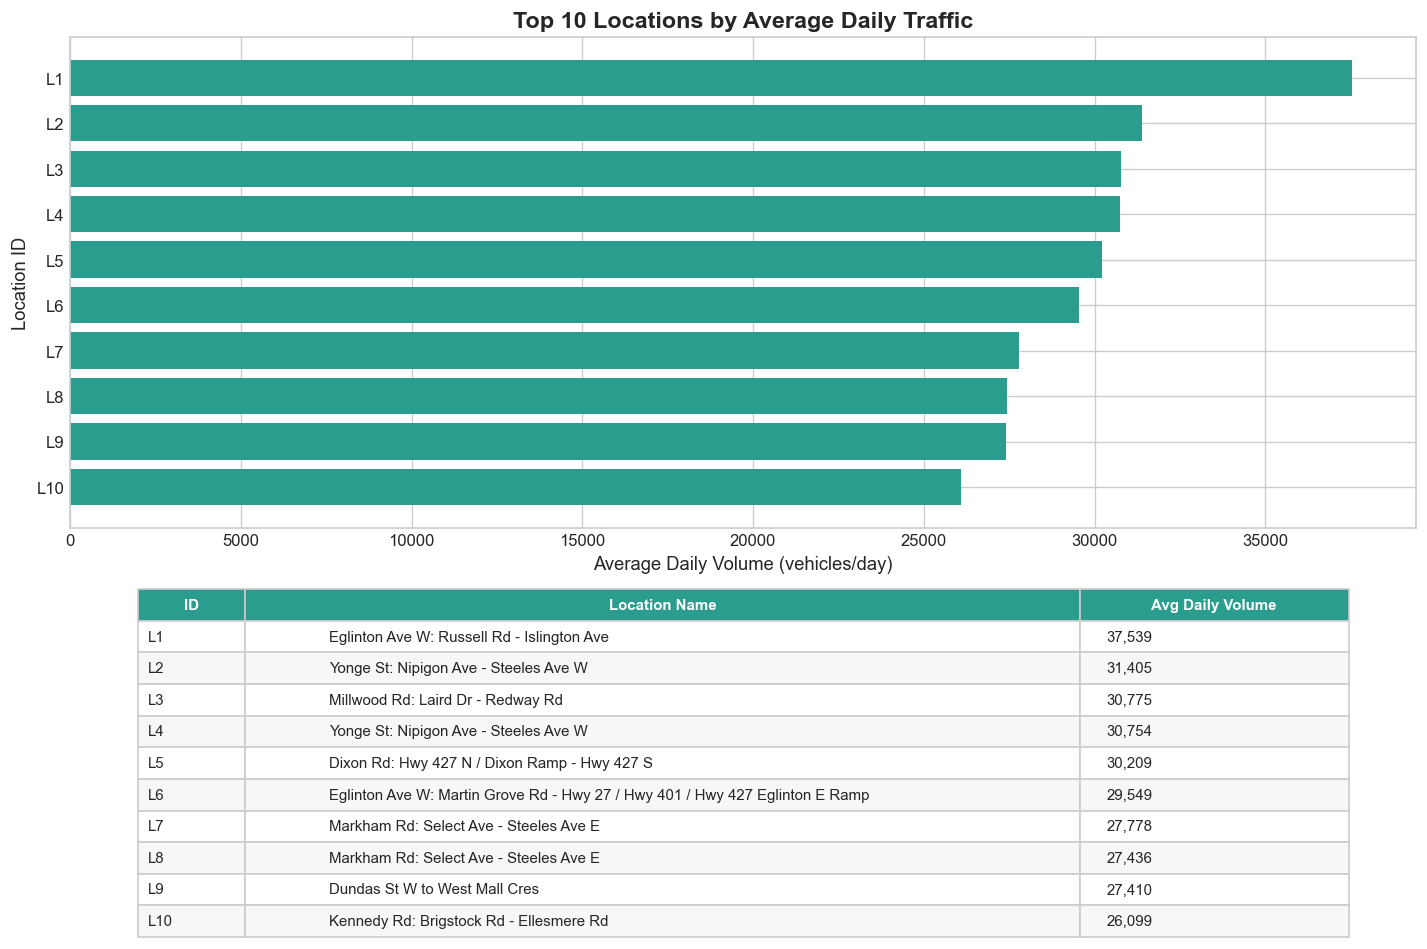

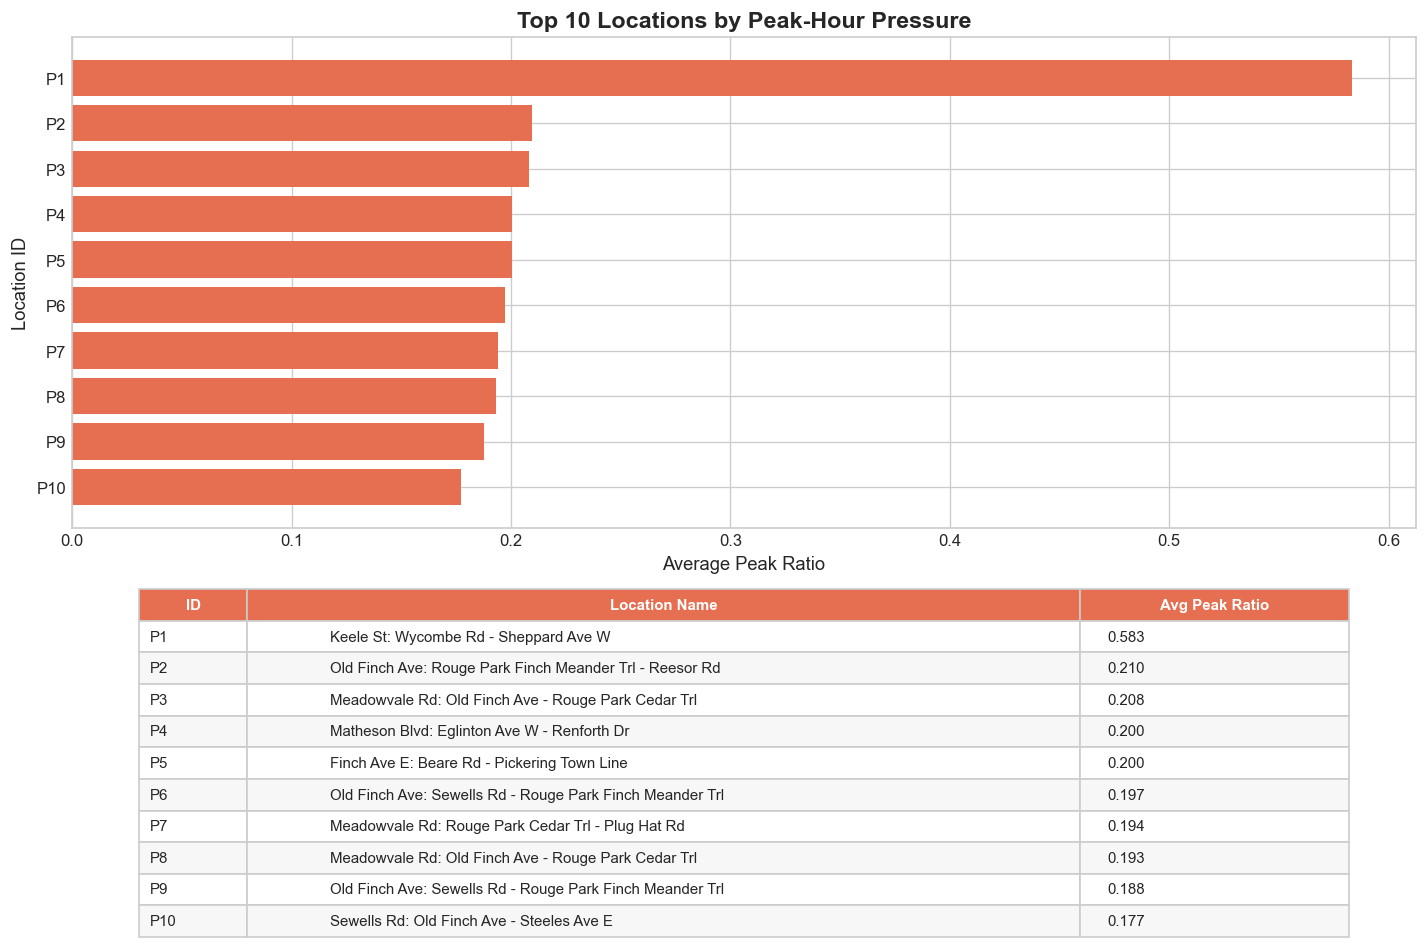

In [15]:
# Create numbered labels for cleaner chart display
top_volume_locations = top_volume_locations.reset_index(drop=True)
top_peak_pressure = top_peak_pressure.reset_index(drop=True)

vol_short = [f"L{i+1}" for i in range(len(top_volume_locations))]
peak_short = [f"P{i+1}" for i in range(len(top_peak_pressure))]

# ── Figure 1: Top 10 by Average Daily Traffic ──
fig1, (ax1_chart, ax1_tbl) = plt.subplots(
    2, 1, figsize=(12, 8), gridspec_kw={"height_ratios": [3, 2]}, tight_layout=True
)

ax1_chart.barh(vol_short, top_volume_locations["avg_daily_volume"], color="#2A9D8F")
ax1_chart.set_title("Top 10 Locations by Average Daily Traffic", fontsize=14, fontweight="bold")
ax1_chart.set_xlabel("Average Daily Volume (vehicles/day)")
ax1_chart.set_ylabel("Location ID")
ax1_chart.invert_yaxis()

ax1_tbl.axis("off")
vol_table_data = [[vol_short[i],
                    top_volume_locations.loc[i, "location_name"],
                    f"{top_volume_locations.loc[i, 'avg_daily_volume']:,.0f}"]
                   for i in range(len(vol_short))]
tbl1 = ax1_tbl.table(
    cellText=vol_table_data,
    colLabels=["ID", "Location Name", "Avg Daily Volume"],
    loc="center", cellLoc="left",
    colWidths=[0.08, 0.62, 0.20],
)
tbl1.auto_set_font_size(False)
tbl1.set_fontsize(9)
tbl1.scale(1, 1.3)
for (row, col), tcell in tbl1.get_celld().items():
    tcell.set_edgecolor("#cccccc")
    if row == 0:
        tcell.set_facecolor("#2A9D8F")
        tcell.set_text_props(color="white", fontweight="bold")
    else:
        tcell.set_facecolor("#f7f7f7" if row % 2 == 0 else "white")
plt.show()

# ── Figure 2: Top 10 by Peak-Hour Pressure ──
fig2, (ax2_chart, ax2_tbl) = plt.subplots(
    2, 1, figsize=(12, 8), gridspec_kw={"height_ratios": [3, 2]}, tight_layout=True
)

ax2_chart.barh(peak_short, top_peak_pressure["avg_peak_ratio"], color="#E76F51")
ax2_chart.set_title("Top 10 Locations by Peak-Hour Pressure", fontsize=14, fontweight="bold")
ax2_chart.set_xlabel("Average Peak Ratio")
ax2_chart.set_ylabel("Location ID")
ax2_chart.invert_yaxis()

ax2_tbl.axis("off")
peak_table_data = [[peak_short[i],
                     top_peak_pressure.loc[i, "location_name"],
                     f"{top_peak_pressure.loc[i, 'avg_peak_ratio']:.3f}"]
                    for i in range(len(peak_short))]
tbl2 = ax2_tbl.table(
    cellText=peak_table_data,
    colLabels=["ID", "Location Name", "Avg Peak Ratio"],
    loc="center", cellLoc="left",
    colWidths=[0.08, 0.62, 0.20],
)
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(9)
tbl2.scale(1, 1.3)
for (row, col), tcell in tbl2.get_celld().items():
    tcell.set_edgecolor("#cccccc")
    if row == 0:
        tcell.set_facecolor("#E76F51")
        tcell.set_text_props(color="white", fontweight="bold")
    else:
        tcell.set_facecolor("#f7f7f7" if row % 2 == 0 else "white")
plt.show()


### Visual Description
This visual presents highest average traffic locations and highest peak-hour pressure locations. The horizontal axis reports average daily volume (vehicles/day) and average peak ratio, and the vertical axis reports location. Together, the figure provides a direct summary of the traffic pattern, model comparison, or operational outcome under study.

### Insight
The main value of this visual is that it makes relative differences immediately visible, which helps confirm whether traffic demand is not uniform across time or space, which is exactly why forecasting and targeted optimization are necessary. That perspective supports clearer discussion of congestion conditions, forecasting performance, and signal-timing decisions during presentation.

Location ranking shows that high total volume and high peak concentration do not always coincide. This distinction is important for selecting intersections where timing improvements can yield measurable congestion relief.

## Interpretation — Operational Insights

In [16]:
candidate_windows = (
    hourly_df.groupby("hour_of_day", as_index=False)
    .agg(
        avg_hourly_volume=("hourly_volume", "mean"),
        avg_peak_flag=("is_peak_hour", "mean"),
    )
    .sort_values(["avg_hourly_volume", "avg_peak_flag"], ascending=False)
    .head(5)
)

display(candidate_windows)


,hour_of_day,avg_hourly_volume,avg_peak_flag
17,17,830.383870,0.325891
16,16,796.923849,0.118380
18,18,754.812565,0.078747
15,15,735.938906,0.066978
8,8,679.954656,0.236068


The strongest optimization candidates are periods and locations where high average demand overlaps with recurrent peak pressure. These EDA findings directly inform forecasting targets and strategy-comparison scenarios.

## Conclusion / Key Takeaways
- EDA confirms recurring temporal demand structure across year, month, weekday, and hour.
- Peak-demand windows and high-pressure locations were identified for operational focus.
- Demand concentration patterns justify targeted, time-sensitive signal strategies rather than uniform treatment.
- These findings provide the empirical basis for forecasting and optimization notebooks.